# Rae2822 2D Wing Slice Model

### Import Library

In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

### Loading Data

In [ ]:
# angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"
angles = sorted(glob.glob(f"{folder_path}*"), key=lambda x: float(x.split('\\')[-1]))
files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filepath in enumerate(angles):
    df = pd.read_csv(filepath+"/surface_flow.csv")

    # apply angles for each case
    df['AoA'] = float(angles[i].split('\\')[-1])

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)
full_data = full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']]
# full_data = full_data.dropna()
print(full_data[full_data.isna().any(axis=1)])


In [ ]:
print(f"Total rows: {len(full_data)}")
full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']].head(300)

In [ ]:
sample_aoa = 6
sample_case = full_data[full_data['AoA'] == sample_aoa]

plt.figure(figsize=(10, 6))
top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.title(f"Sample Case: AoA = {sample_aoa}°")

# Model

In [69]:
# import model
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [70]:
full_data['AoA_rad'] = np.deg2rad(full_data['AoA'])
full_data['sin_AoA'] = np.sin(full_data['AoA_rad'])
full_data['cos_AoA'] = np.cos(full_data['AoA_rad'])

# features = ['x', 'y', 'AoA']
features = ['x', 'y', 'sin_AoA', 'cos_AoA']
target = 'Pressure_Coefficient'

In [91]:
def build_model():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3)),
        tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3)),
        tf.keras.layers.Dense(1, kernel_regularizer=tf.keras.regularizers.l2(1e-3))
    ])

def build_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,          
        restore_best_weights=True
    )

logo = LeaveOneGroupOut()

aoa_values = full_data['AoA'].values
unique_aoas = np.unique(aoa_values)
X = full_data[features].values  # shape (n*192, 3)
y = full_data[target].values    # shape (n*192, 1)

val_scores = []
train_val_ratio = []
_round = 0

for train_idx, test_idx in logo.split(X, y, aoa_values):
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s  = scaler_X.transform(X_test)

    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
    y_test_s  = scaler_y.transform(y_test.reshape(-1, 1))

    model = build_model()

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae'] # meaningful for regression
    )

    history = model.fit(
        X_train_s, y_train_s,
        epochs=200,
        validation_split=0.1,
        callbacks=[build_early_stop()],
        verbose=0
    )

    final_train = history.history['loss'][-1]
    actual_epochs = len(history.history['loss'])
    final_val   = history.history['val_loss'][-1]
    gap_ratio   = final_val / final_train

    y_pred_s = model.predict(X_test_s)
    y_pred   = scaler_y.inverse_transform(y_pred_s)

    mse = np.mean((y_pred - y_test)**2)
    mae = np.mean(np.abs(y_pred - y_test))

    # score = model.evaluate(y_test, y_pred, verbose=0) # mse, mae
    val_scores.append([mse, mae])
    train_val_ratio.append(gap_ratio)
    print(f"AoA {unique_aoas[_round]} → train: {final_train:.5f} | val: {final_val:.5f} | ratio: {gap_ratio:.2f}")
    print(f"\tStopped: {actual_epochs} epochs | MSE: {mse:.5f} | MAE: {mae:.5f}")
    _round += 1

print(f"\nMean MSE: {np.mean(val_scores[0]):.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 0.0 → train: 0.04359 | val: 0.08546 | ratio: 1.96
	Stopped: 88 epochs | MSE: 0.33319 | MAE: 0.44945
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
AoA 0.5 → train: 0.04300 | val: 0.09398 | ratio: 2.19
	Stopped: 55 epochs | MSE: 0.38127 | MAE: 0.48526
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 1.0 → train: 0.04537 | val: 0.09288 | ratio: 2.05
	Stopped: 70 epochs | MSE: 0.45593 | MAE: 0.53982
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
AoA 1.5 → train: 0.04540 | val: 0.07944 | ratio: 1.75
	Stopped: 77 epochs | MSE: 0.54241 | MAE: 0.58986
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 2.0 → train: 0.04568 | val: 0.08468 | ratio: 1.85
	Stopped: 55 epochs | MSE: 0.63099 | MAE: 0.63665
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 2.5 → train: 0.04343 | val: 0.09247 | ratio: 2.13
	Stopped: 91 epochs | MSE: 0.77213 | MAE: 0.70312
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 3.0 → train: 0.04556 | val: 0.08098 | ratio: 1.78
	Stopped: 50 epochs | MSE: 0.92201 | MAE: 0.76538
6/6 ━━

In [92]:
unique_aoas = np.unique(aoa_values)
for i, (aoa, score, ratio) in enumerate(zip(unique_aoas, val_scores, train_val_ratio)):
    print(f"AoA {aoa }° → MSE: {score[0]:.5f}, MAE: {score[1]:.5f}, Ratio: {ratio:.2f}")

AoA 0.0° → MSE: 0.33319, MAE: 0.44945, Ratio: 1.96
AoA 0.5° → MSE: 0.38127, MAE: 0.48526, Ratio: 2.19
AoA 1.0° → MSE: 0.45593, MAE: 0.53982, Ratio: 2.05
AoA 1.5° → MSE: 0.54241, MAE: 0.58986, Ratio: 1.75
AoA 2.0° → MSE: 0.63099, MAE: 0.63665, Ratio: 1.85
AoA 2.5° → MSE: 0.77213, MAE: 0.70312, Ratio: 2.13
AoA 3.0° → MSE: 0.92201, MAE: 0.76538, Ratio: 1.78
AoA 3.5° → MSE: 1.00327, MAE: 0.79968, Ratio: 1.77
AoA 4.0° → MSE: 1.06503, MAE: 0.82301, Ratio: 1.90
AoA 4.5° → MSE: 1.14067, MAE: 0.85126, Ratio: 2.21
AoA 5.0° → MSE: 1.15975, MAE: 0.85831, Ratio: 1.80
AoA 5.5° → MSE: 1.19446, MAE: 0.87328, Ratio: 1.77
AoA 6.0° → MSE: 1.23571, MAE: 0.88931, Ratio: 2.18
AoA 6.5° → MSE: 1.24358, MAE: 0.89276, Ratio: 1.96
AoA 7.0° → MSE: 1.23433, MAE: 0.89038, Ratio: 2.40
AoA 7.5° → MSE: 1.21992, MAE: 0.88418, Ratio: 1.95
AoA 8.0° → MSE: 1.18328, MAE: 0.87137, Ratio: 1.88
AoA 8.5° → MSE: 1.20119, MAE: 0.87787, Ratio: 1.52
AoA 9.0° → MSE: 1.15845, MAE: 0.86125, Ratio: 1.97
AoA 9.5° → MSE: 1.08535, MAE: 0

In [ ]:
# train final model with full dataset
final_scaler_X = StandardScaler()
final_scaler_y = StandardScaler()

full_feature = full_data[features].values
full_target = full_data[target].values

full_X_s = final_scaler_X.fit_transform(full_feature)
full_y_s = final_scaler_y.fit_transform(full_target.reshape(-1, 1))

final_model = build_model()

final_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
final_model.fit(
        full_X_s, full_y_s,
        epochs=200,
        validation_split=0.1,
        callbacks=[build_early_stop()],
        verbose=0
    )


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


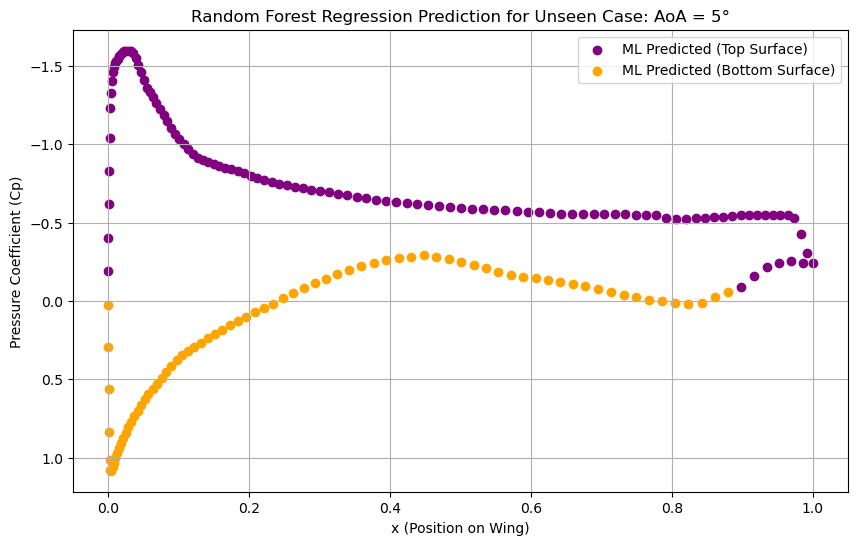

In [ ]:
predict_aoa = 5

# predict_scaler_X = StandardScaler()
# predict_scaler_y = StandardScaler()

geometry = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)

X_new = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)
X_new['sin_AoA'] = np.sin(np.deg2rad(predict_aoa))
X_new['cos_AoA'] = np.cos(np.deg2rad(predict_aoa))

# predict
X_new_s = final_scaler_X.fit_transform(X_new[features])

Cp_predicted_s = final_model.predict(X_new_s)
Cp_predicted = final_scaler_y.inverse_transform(Cp_predicted_s)

# map back — just attach prediction to the same rows
result = X_new[features].copy()
result['Cp_predicted'] = Cp_predicted

# print(result)


plt.figure(figsize=(10, 6))
top_surface = result[result['y'] > 0].sort_values(by='x')
bottom_surface = result[result['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title(f"Random Forest Regression Prediction for Unseen Case: AoA = {predict_aoa}°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
aoa_degrees = np.linspace(0, 360, 100)
aoa_radians = np.deg2rad(aoa_degrees)

# 2. Apply the Trigonometric Normalization
sin_aoa = np.sin(aoa_radians)
cos_aoa = np.cos(aoa_radians)

# 3. Create a side-by-side visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: The Bounded Waves ---
ax1.plot(aoa_degrees, sin_aoa, label='sin_AoA', color='blue', linewidth=2)
ax1.plot(aoa_degrees, cos_aoa, label='cos_AoA', color='red', linewidth=2, linestyle='--')
ax1.set_title("1. Bounding Features between [-1, 1]")
ax1.set_xlabel("Original Angle of Attack (Degrees)")
ax1.set_ylabel("Normalized Feature Value")
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.legend()
ax1.grid(True, alpha=0.4)

# --- Plot 2: The Unit Circle Projection ---
# We use color to map back to the original angle
cmap = plt.cm.cool
scatter = ax2.scatter(cos_aoa, sin_aoa, c=aoa_degrees, cmap='twilight_shifted', edgecolor='k')
ax2.set_title("2. New Feature Space (Cyclical Continuity)")
ax2.set_xlabel("cos_AoA")
ax2.set_ylabel("sin_AoA")
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax2.set_aspect('equal') # Forces the axes to be proportional (perfect circle)
plt.colorbar(scatter, ax=ax2, label='Original AoA (Degrees)')

plt.tight_layout()
plt.show()